In [30]:
import requests
from bs4 import BeautifulSoup

import time

stock_urls = {
    "Merolagani": "https://merolagani.com/latestmarket.aspx",
    # "Sharesansar": "https://www.sharesansar.com/"
}

stock_data = []
responses = {}

for name, url in stock_urls.items():
    try:
        response = requests.get(url, timeout=10)
        responses[name] = response
        print(f"✓ {name}: Status {response.status_code}")
        time.sleep(1)  
    except Exception as e:
        print(f"✗ {name}: {str(e)}")


✓ Merolagani: Status 200


In [31]:
stock_data = []
for name, response in responses.items():
    if response.status_code != 200:
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    table = soup.find("table")
    #if no table then 
    if not table:
        continue

    rows = table.find("tbody").find_all("tr")

    for row in rows:
        cols = row.find_all("td")

        if len(cols) < 7:
            continue

        symbol = cols[0].text.strip()
        ltp = cols[1].text.strip()
        percent_change = cols[2].text.strip()
        open_price = cols[3].text.strip()
        high = cols[4].text.strip()
        low = cols[5].text.strip()
        quantity = cols[6].text.strip()

        stock_data.append({
            "symbol": symbol,
            "ltp": float(ltp.replace(",", "")),
            "percent_change": float(percent_change),
            "open": float(open_price.replace(",", "")),
            "high": float(high.replace(",", "")),
            "low": float(low.replace(",", "")),
            "quantity": int(quantity.replace(",", ""))
        })


In [32]:
import pandas as pd

df = pd.DataFrame(stock_data)

df


,symbol,ltp,percent_change,open,high,low,quantity
0,ACLBSL,943.0,-0.74,969.0,943.0,968.0,3235
1,ADBL,298.0,-0.33,304.8,296.2,302.0,10054
2,ADBLD83,1050.7,-0.03,1050.8,1050.7,1050.8,105
3,AHL,552.0,-1.94,566.0,552.0,563.0,5921
4,AHPC,264.0,-0.79,270.0,264.0,267.0,90441
...,...,...,...,...,...,...,...
317,USHL,770.0,-2.52,805.6,761.0,805.6,11370
318,USLB,1460.0,-0.68,1490.0,1445.0,1470.0,3809
319,VLBS,766.0,-0.04,780.0,765.0,779.9,3162
320,VLUCL,575.1,1.41,583.1,566.5,577.9,9496


In [33]:
df.to_csv("Stock_Price.csv")

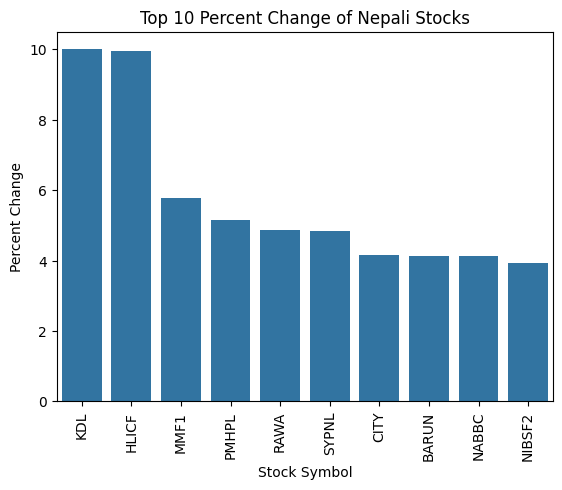

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = df.sort_values('percent_change', ascending=False).head(10)

sns.barplot(x='symbol', y='percent_change', data=top10)
plt.xticks(rotation=90)
plt.title('Top 10 Percent Change of Nepali Stocks')
plt.xlabel('Stock Symbol')
plt.ylabel('Percent Change')
plt.show()


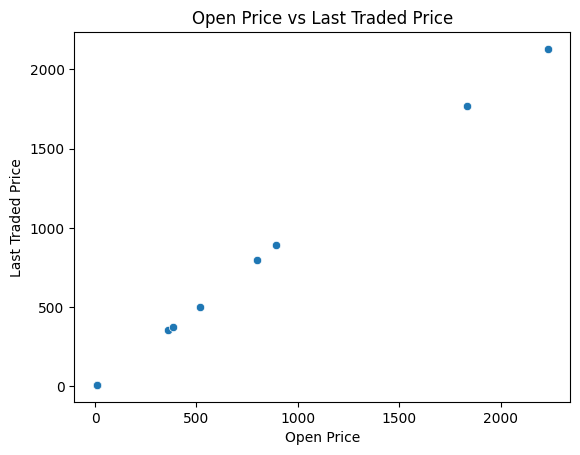

In [35]:
sns.scatterplot(x='open', y='ltp', data=top10)
plt.title('Open Price vs Last Traded Price')
plt.xlabel('Open Price')
plt.ylabel('Last Traded Price')
plt.show()

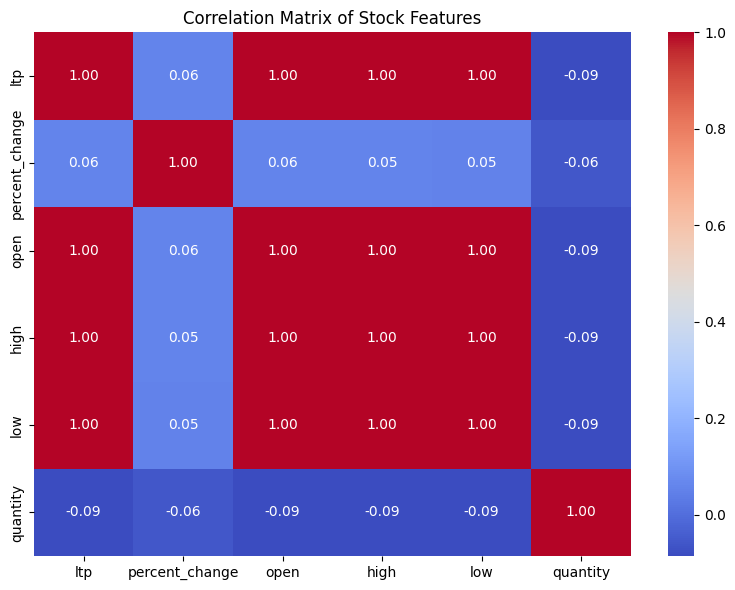

In [36]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Features')
plt.tight_layout()
plt.show()